# Cricket Analytics – Sports Industry

## IPL 2026 Data Analysis using Python

### Objective

**The objective of this project is to analyze IPL 2024 ball-by-ball data using Python. This project focuses on player performance, team performance, strike rate, economy rate, phase-wise analysis, and visualizations to generate meaningful insights.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import swaborn as sns



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\nandi\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\nandi\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\nandi\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\nandi\AppData\Roaming\Python\

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\nandi\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\nandi\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\nandi\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\nandi\AppData\Roaming\Python\

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ModuleNotFoundError: No module named 'swaborn'

**Load Data**

In [2]:
df = pd.read_csv("ipl_2026_deliveries.csv")
df.head()

,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,...,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,...,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
1,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,...,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN
2,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,...,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
3,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,...,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN
4,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,...,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN


In [3]:
df.shape   # rows and col

(17477, 21)

In [4]:
df.columns

Index(['match_id', 'season', 'phase', 'match_no', 'date', 'venue',
       'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler',
       'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs',
       'wicket_type', 'player_dismissed', 'fielder'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17477 entries, 0 to 17476
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          17477 non-null  int64  
 1   season            17477 non-null  int64  
 2   phase             17477 non-null  str    
 3   match_no          17477 non-null  int64  
 4   date              17477 non-null  str    
 5   venue             17477 non-null  str    
 6   batting_team      17477 non-null  str    
 7   bowling_team      17477 non-null  str    
 8   innings           17477 non-null  int64  
 9   over              17477 non-null  float64
 10  striker           17477 non-null  str    
 11  bowler            17477 non-null  str    
 12  runs_of_bat       17477 non-null  int64  
 13  extras            17477 non-null  int64  
 14  wide              17477 non-null  int64  
 15  legbyes           17477 non-null  int64  
 16  byes              17477 non-null  int64  
 17  noba

In [6]:
df.isnull().sum()

match_id                0
season                  0
phase                   0
match_no                0
date                    0
venue                   0
batting_team            0
bowling_team            0
innings                 0
over                    0
striker                 0
bowler                  0
runs_of_bat             0
extras                  0
wide                    0
legbyes                 0
byes                    0
noballs                 0
wicket_type         16598
player_dismissed    16602
fielder             16791
dtype: int64

**How many matches are played**

In [8]:
df['match_id'].nunique()

74

**How many teams are playing**

In [9]:
df['batting_team'].unique()

<ArrowStringArray>
['SRH', 'RCB', 'KKR', 'MI', 'CSK', 'RR', 'GT', 'PBKS', 'LSG', 'DC']
Length: 10, dtype: str

In [10]:
df['batting_team'].nunique()

10

**feature Engineering-Creating new columns**

In [16]:
df['total_runs'] = df['runs_of_bat'] + df['extras']   # total run on each ball

df['is_six'] = 0
df['is_four'] = 0
df['is_wicket'] = 0

df.loc[df['runs_of_bat']==6,'is_six'] = 1 #runsof bat is 6
df.loc[df['runs_of_bat']==4,'is_four'] = 1 
df.loc[df['wicket_type'].notnull(),'is_wicket']=1

df.head()


,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,...,noballs,wicket_type,player_dismissed,fielder,total_runs,is_six,is_four,is_wicket,is-six,phase_group
0,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.1,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)
1,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.2,...,0,NaN,NaN,NaN,1,0,0,0,NaN,Powerplay(1-6)
2,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.3,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)
3,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.4,...,0,NaN,NaN,NaN,6,1,0,0,1.0,Powerplay(1-6)
4,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.5,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)


In [12]:
df['over'] = df['over'] + 1

def get_phase(over):
    if over <= 6:
        return 'Powerplay(1-6)'
    elif over <= 15:
        return 'Middle(7-15)'
    else:
        return 'Death(16-20)'

df['phase_group'] = df['over'].apply(get_phase)

df

,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,...,noballs,wicket_type,player_dismissed,fielder,total_runs,is_six,is_four,is_wicket,is-six,phase_group
0,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.1,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)
1,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.2,...,0,NaN,NaN,NaN,1,0,0,0,NaN,Powerplay(1-6)
2,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.3,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)
3,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.4,...,0,NaN,NaN,NaN,6,0,0,0,1.0,Powerplay(1-6)
4,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.5,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17472,202674,2026,Final,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,2,18.2,...,0,NaN,NaN,NaN,1,0,0,0,NaN,Death(16-20)
17473,202674,2026,Final,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,2,18.3,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Death(16-20)
17474,202674,2026,Final,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,2,18.4,...,0,NaN,NaN,NaN,1,0,0,0,NaN,Death(16-20)
17475,202674,2026,Final,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,2,18.5,...,0,NaN,NaN,NaN,4,0,0,0,1.0,Death(16-20)


**Batting Analysis**
**Which Team Scored the most runs**

In [13]:
edf = df.groupby('batting_team').agg(
    total=('total_runs', 'sum')
).reset_index()

edf = edf.sort_values('total', ascending=False)

edf

,batting_team,total
2,GT,3083
8,RR,3071
7,RCB,3054
9,SRH,3041
6,PBKS,2704
1,DC,2552
5,MI,2552
0,CSK,2523
4,LSG,2505
3,KKR,2311


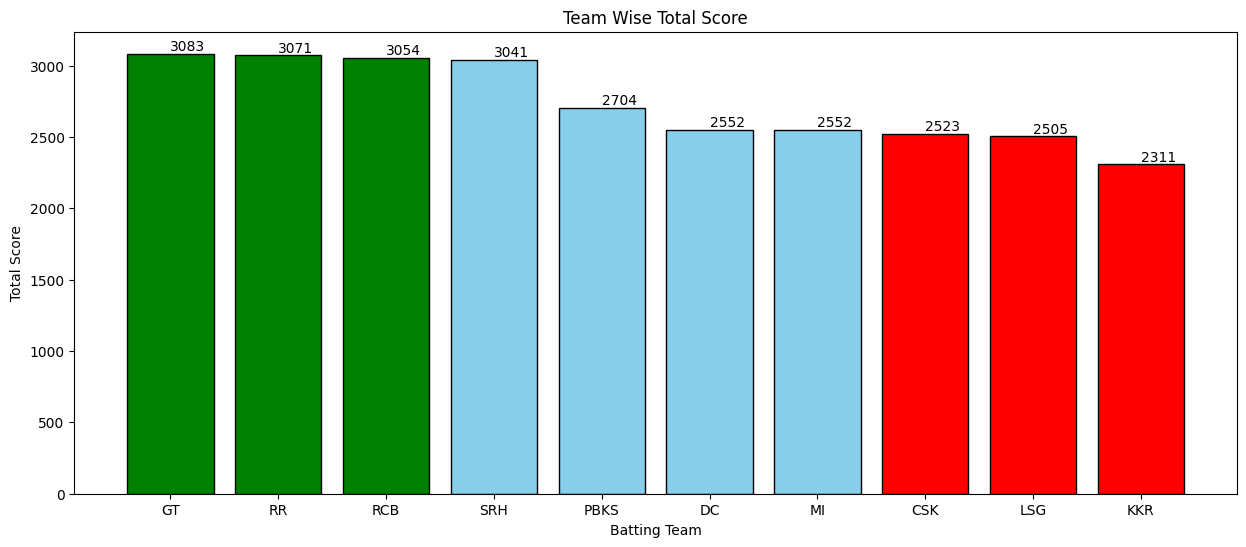

In [14]:
plt.figure(figsize=(15,6))
plt.bar(edf['batting_team'],edf['total'],color=['green','green','green','skyblue','skyblue','skyblue','skyblue','red','red','red'],edgecolor='black')
plt.title('Team Wise Total Score')
plt.xlabel('Batting Team')
plt.ylabel('Total Score')

for x,y in zip(edf['batting_team'],edf['total']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

**Team with most sixes and fours**

In [17]:
edf = df.groupby('batting_team').agg(
    nos = ('is_six','sum'),
    nof = ('is_four','sum')
).reset_index()

edf['score by boundaries'] = edf['nos'] + edf['nof']
edf

,batting_team,nos,nof,score by boundaries
0,CSK,124,220,344
1,DC,117,225,342
2,GT,124,292,416
3,KKR,115,192,307
4,LSG,127,208,335
5,MI,140,204,344
6,PBKS,163,219,382
7,RCB,164,261,425
8,RR,181,257,438
9,SRH,171,255,426


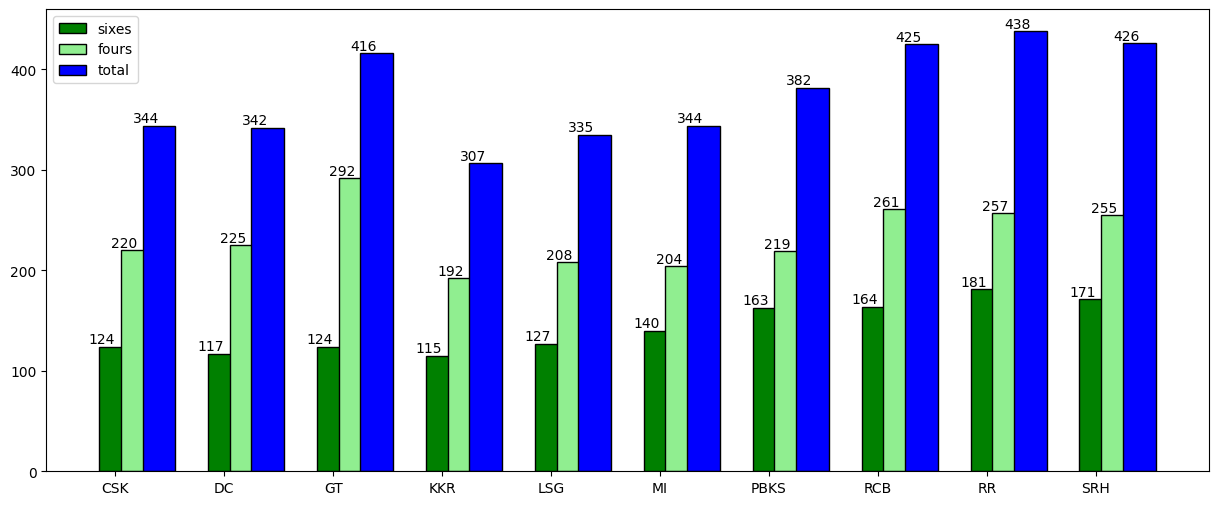

In [18]:
plt.figure(figsize=(15,6))

xval = np.arange(1,11)  #[1,2,3,4,5,6,7,8,9,10]

plt.bar(xval,edf['nos'],width=0.3,color='green',label='sixes',edgecolor='black')  #[1 2 3 4 5 6 7 8 9 10]
plt.bar(xval+0.2,edf['nof'],width=0.3,color='lightgreen',label='fours',edgecolor='black') #[1.2,2.2,3.2,4.2,5.2,6.2,7.2,8.2,9.2,10.2]
plt.bar(xval+0.4,edf['score by boundaries'],width=0.3,color='blue',label='total',edgecolor='black')
plt.legend()


for x,y in zip(xval,edf['nos']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.2,edf['nof']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.4,edf['score by boundaries']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')


plt.xticks(xval,edf['batting_team'])

plt.show()

**How many runs did each team score in Powerplay, Middle & Death overs?**

In [20]:
edf = df.groupby(['batting_team','phase_group']).agg(
    total = ('total_runs','sum')
).reset_index()

edf = edf.sort_values(['batting_team','total'],ascending=False)
edf

,batting_team,phase_group,total
28,SRH,Middle(7-15),1393
27,SRH,Death(16-20),839
29,SRH,Powerplay(1-6),809
25,RR,Middle(7-15),1404
26,RR,Powerplay(1-6),885
24,RR,Death(16-20),782
22,RCB,Middle(7-15),1315
23,RCB,Powerplay(1-6),878
21,RCB,Death(16-20),861
19,PBKS,Middle(7-15),1176


In [21]:
edf = df.pivot_table(index='batting_team',columns='phase_group',values='total_runs',aggfunc='sum').reset_index()
edf

phase_group,batting_team,Death(16-20),Middle(7-15),Powerplay(1-6)
0,CSK,758,1060,705
1,DC,792,1136,624
2,GT,830,1429,824
3,KKR,635,1069,607
4,LSG,746,1065,694
5,MI,758,1191,603
6,PBKS,813,1176,715
7,RCB,861,1315,878
8,RR,782,1404,885
9,SRH,839,1393,809


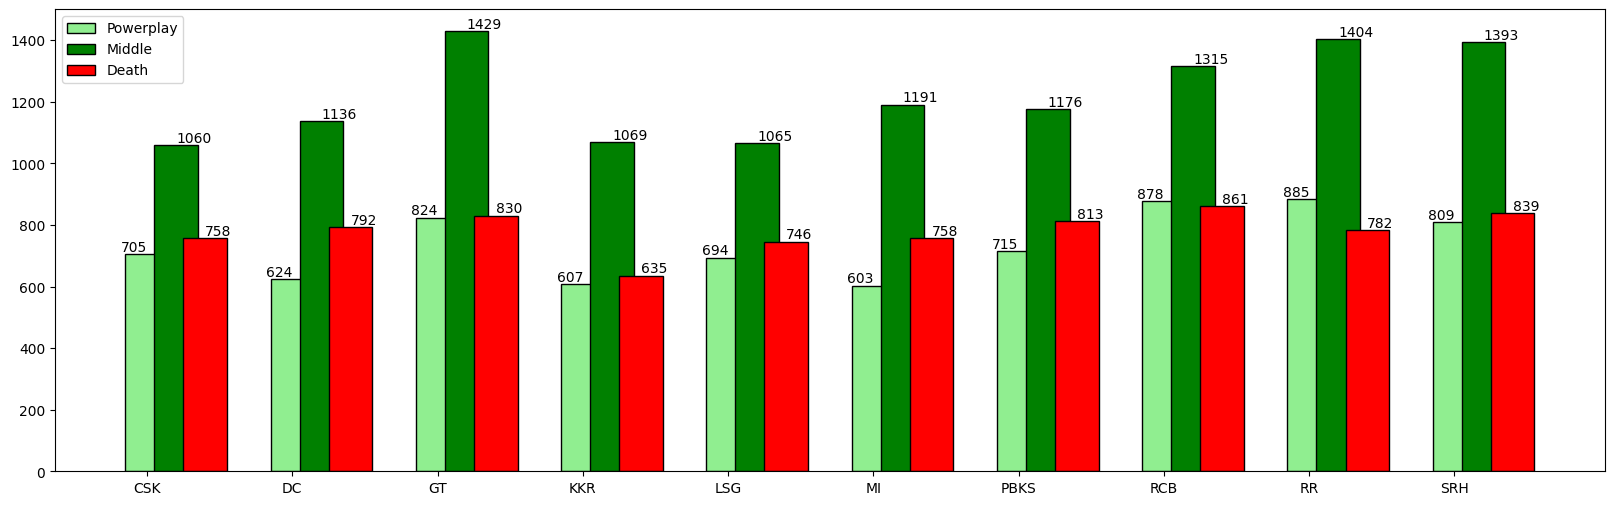

In [22]:
plt.figure(figsize=(20,6))

xval = np.arange(1,11)  #[1,2,3,4,5,6,7,8,9,10]

plt.bar(xval,edf['Powerplay(1-6)'],width=0.3,color='lightgreen',label='Powerplay',edgecolor='black')  #[1 2 3 4 5 6 7 8 9 10]
plt.bar(xval+0.2,edf['Middle(7-15)'],width=0.3,color='green',label='Middle',edgecolor='black') #[1.2,2.2,3.2,4.2,5.2,6.2,7.2,8.2,9.2,10.2]
plt.bar(xval+0.4,edf['Death(16-20)'],width=0.3,color='red',label='Death',edgecolor='black')
plt.legend()


for x,y in zip(xval,edf['Powerplay(1-6)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.2,edf['Middle(7-15)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='left')

for x,y in zip(xval+0.4,edf['Death(16-20)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='left')


plt.xticks(xval,edf['batting_team'])

plt.show()

### Batsman Analysis

**Top 10 scorers In IPL 2026**

In [23]:
edf = df.groupby('striker').agg(
    total = ('total_runs','sum')
).reset_index()

edf = edf.sort_values('total',ascending=False).head(10)
edf

,striker,total
166,Vaibhav Sooryavanshi,797
149,Shubman Gill,772
132,Sai Sudharsan,760
171,Virat Kohli,712
51,Heinrich Klaasen,647
53,Ishan Kishan,618
112,Rahul,614
2,Abhishek Sharma,608
85,Mitchell Marsh,597
62,Jos Buttler,548


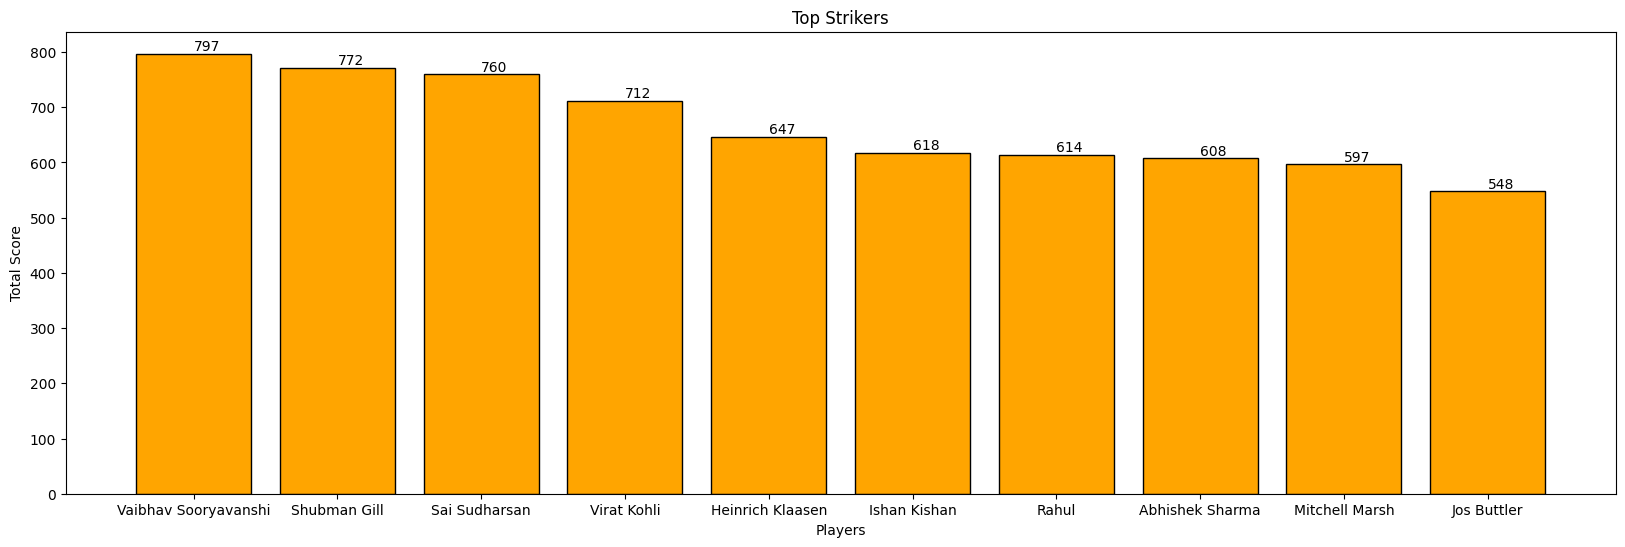

In [24]:
plt.figure(figsize=(20,6))
plt.bar(edf['striker'],edf['total'],color='orange',edgecolor='black')
plt.title('Top Strikers')
plt.xlabel('Players')
plt.ylabel('Total Score')

for x,y in zip(edf['striker'],edf['total']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

### Top Batsmen (Boundaries)

In [25]:
b = 'is_four'
edf = df.groupby('striker').agg(
    total = (b,'sum')
).reset_index()
edf = edf.sort_values('total',ascending=False).head(10)
edf

,striker,total
132,Sai Sudharsan,75
149,Shubman Gill,74
171,Virat Kohli,73
166,Vaibhav Sooryavanshi,63
53,Ishan Kishan,60
112,Rahul,56
105,Prabhsimran Singh,55
136,Sanju Samson,53
176,Yashasvi Jaiswal,52
62,Jos Buttler,51


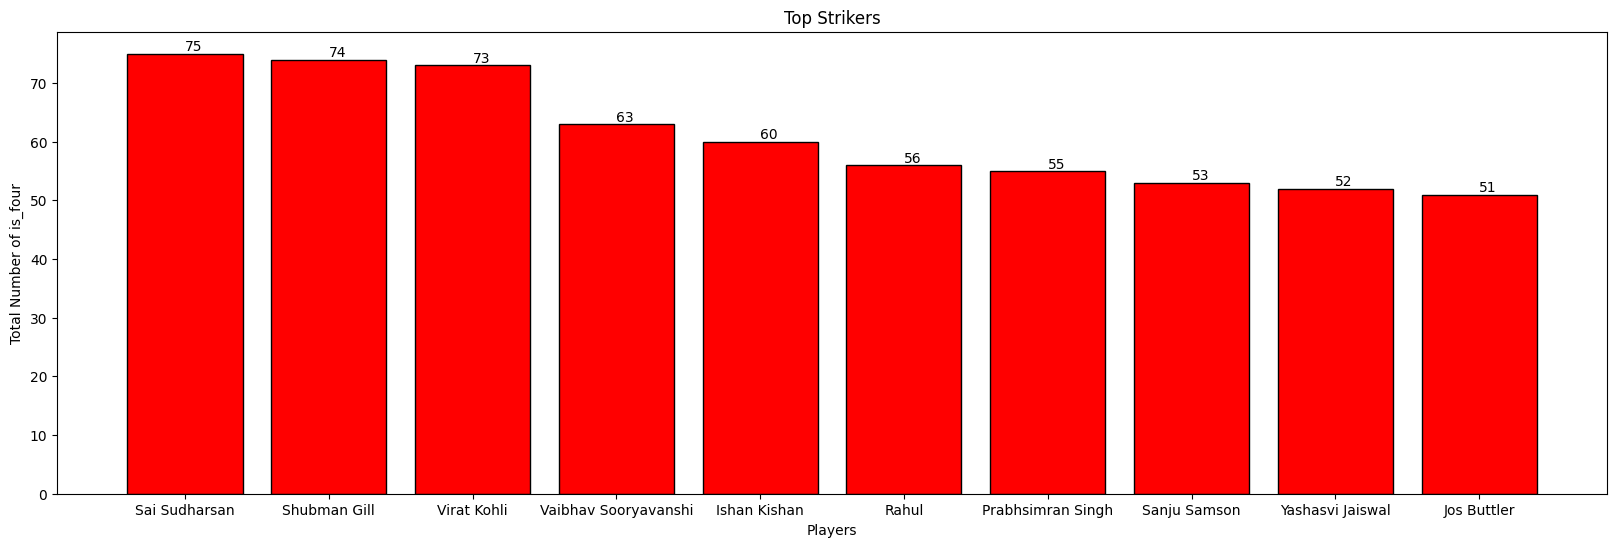

In [26]:
plt.figure(figsize=(20,6))
plt.bar(edf['striker'],edf['total'],color='red',edgecolor='black')
plt.title('Top Strikers')
plt.xlabel('Players')
plt.ylabel(f'Total Number of {b}')

for x,y in zip(edf['striker'],edf['total']):
    plt.text(x=x,y=y,s=y,va='bottom')

## Strike Rate for Top Batsmen
- formulae : (runs score / ball faced) * 100
- wide ball != balls faced

In [27]:
egal_balls = df.loc[ df['extras']==0 ]

edf = df.groupby('striker').agg(
    runs = ('runs_of_bat','sum'),
    balls = ('runs_of_bat','count')
).reset_index()

edf = edf.loc[ edf['balls']>=30 ]
edf['strike_rate'] = (edf['runs']/edf['balls'])*100
edf = edf.sort_values('strike_rate',ascending=False).head(10)
edf['strike_rate'] = edf['strike_rate'].round().astype(int)
edf

,striker,runs,balls,strike_rate
166,Vaibhav Sooryavanshi,776,342,227
44,Finn Allen,349,168,208
110,Priyansh Arya,364,181,201
164,Urvil Patel,129,67,193
2,Abhishek Sharma,563,301,187
115,Rajat Patidar,500,274,182
130,Ryan Rickelton,448,247,181
168,Venkatesh Iyer,209,116,180
158,Tim David,305,172,177
53,Ishan Kishan,604,343,176


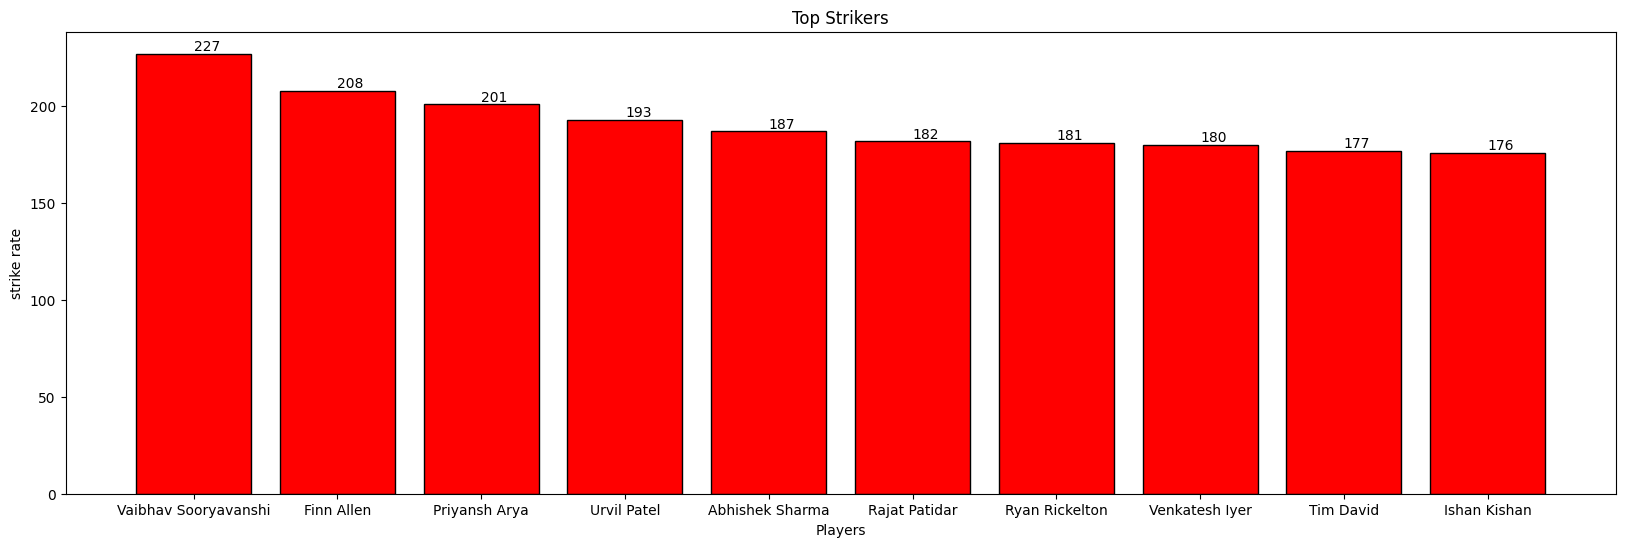

In [28]:
plt.figure(figsize=(20,6))
plt.bar(edf['striker'],edf['strike_rate'],color='red',edgecolor='black')
plt.title('Top Strikers')
plt.xlabel('Players')
plt.ylabel('strike rate')

for x,y in zip(edf['striker'],edf['strike_rate']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

## Bowler Analysis
## Most wickets in IPL 2026 - Bowlers
**run-outs are not credited to the bowler**

In [29]:
df

,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,...,noballs,wicket_type,player_dismissed,fielder,total_runs,is_six,is_four,is_wicket,is-six,phase_group
0,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.1,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)
1,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.2,...,0,NaN,NaN,NaN,1,0,0,0,NaN,Powerplay(1-6)
2,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.3,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)
3,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.4,...,0,NaN,NaN,NaN,6,1,0,0,1.0,Powerplay(1-6)
4,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.5,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Powerplay(1-6)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17472,202674,2026,Final,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,2,18.2,...,0,NaN,NaN,NaN,1,0,0,0,NaN,Death(16-20)
17473,202674,2026,Final,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,2,18.3,...,0,NaN,NaN,NaN,0,0,0,0,NaN,Death(16-20)
17474,202674,2026,Final,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,2,18.4,...,0,NaN,NaN,NaN,1,0,0,0,NaN,Death(16-20)
17475,202674,2026,Final,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,2,18.5,...,0,NaN,NaN,NaN,4,0,1,0,1.0,Death(16-20)


In [30]:
bowler_wickets = df.loc[  (df['wicket_type'].notnull()) & (df['wicket_type']!='runout') ]


edf = bowler_wickets.groupby('bowler').agg(
    total = ('is_wicket','sum')
).reset_index()

edf = edf.sort_values('total',ascending=False).head(10)
edf

,bowler,total
40,Kagiso Rabada,29
15,Bhuvneshwar Kumar,28
38,Jofra Archer,25
4,Anshul Kamboj,21
73,Rashid Khan,21
74,Rasikh Salam Dar,20
26,Eshan Malinga,20
57,Mohammed Siraj,19
41,Kartik Tyagi,18
35,Jason Holder,17


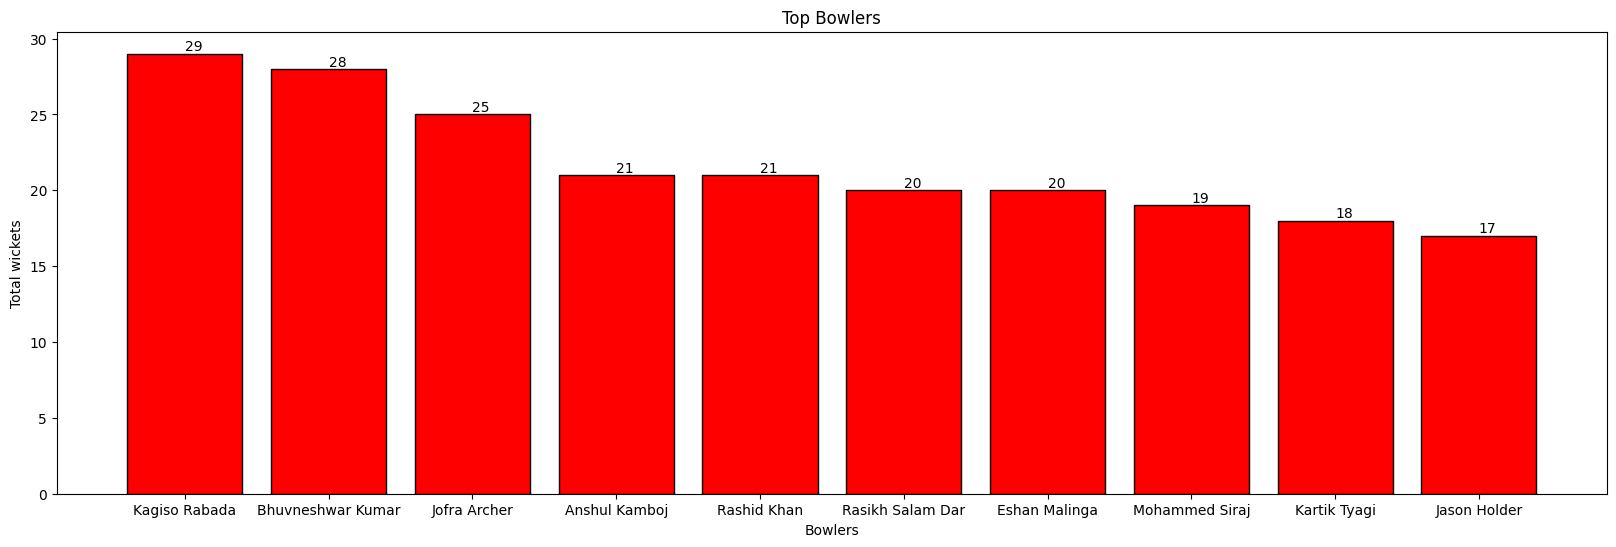

In [31]:
plt.figure(figsize=(20,6))
plt.bar(edf['bowler'],edf['total'],color='red',edgecolor='black')
plt.title('Top Bowlers')
plt.xlabel('Bowlers')
plt.ylabel('Total wickets')

for x,y in zip(edf['bowler'],edf['total']):
    plt.text(x=x,y=y,s=y,va='bottom')


plt.show()

## Which Bowler has best economy rate
**runs given per over**

In [32]:
legal_balls = df.loc[ (df['wide']==0) & (df['noballs']==0) ]

edf = df.groupby('bowler').agg(
    total = ('runs_of_bat','sum'),
    balls = ('runs_of_bat','count')
).reset_index()

edf = edf.loc[ edf['balls']>=18 ]
edf['economy_rate'] = (edf['total']/edf['balls'])*6
edf = edf.sort_values('economy_rate').head(10)
edf

,bowler,total,balls,economy_rate
102,Saurabh Dubey,92,85,6.494118
109,Sunil Narine,340,309,6.601942
59,Madhav Tiwari,78,68,6.882353
8,Anrich Nortje,32,27,7.111111
32,Dilshan Madushanka,32,27,7.111111
44,Jason Holder,284,236,7.220339
39,Harpreet Brar,59,49,7.224490
45,Jasprit Bumrah,385,317,7.287066
22,Bhuvneshwar Kumar,487,391,7.473146
7,Akeal Hosein,194,151,7.708609


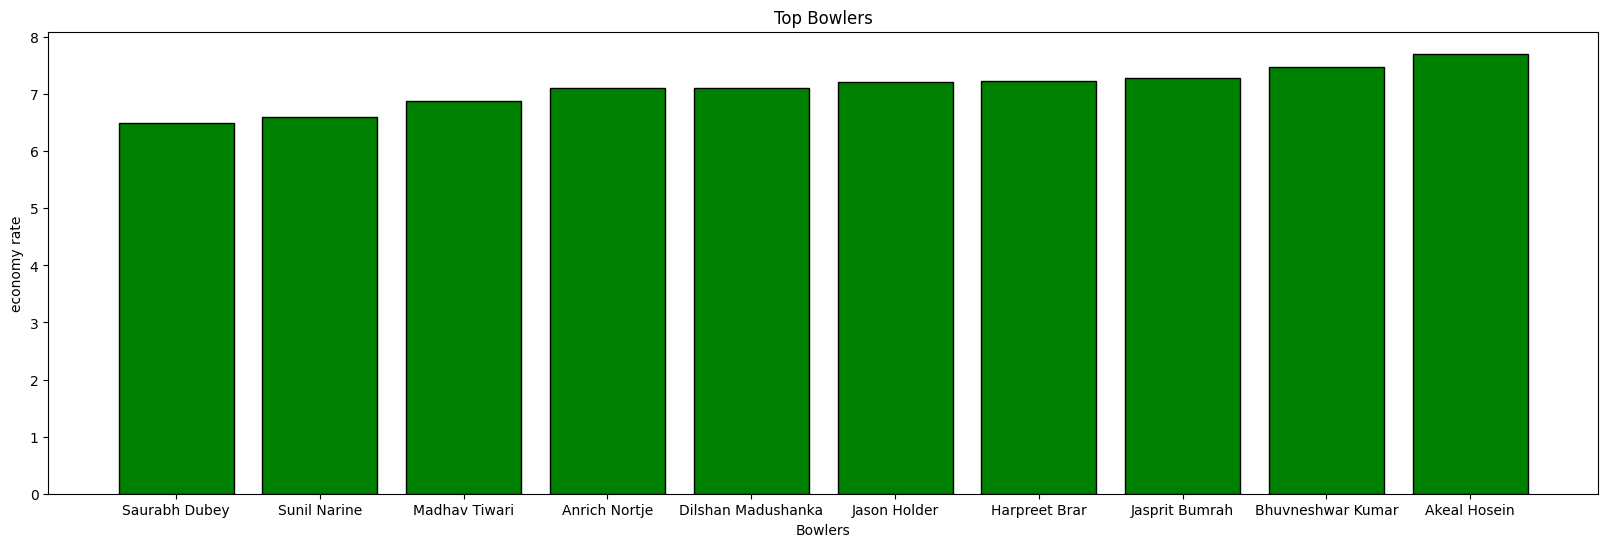

In [33]:
plt.figure(figsize=(20,6))
plt.bar(edf['bowler'],edf['economy_rate'],color='green',edgecolor='black')
plt.title('Top Bowlers')
plt.xlabel('Bowlers')
plt.ylabel('economy rate')
plt.show()

## How are batsmen getting out (wicket type breakdown)

In [34]:
edf = df['wicket_type'].value_counts().reset_index()
edf

,wicket_type,count
0,caught,660
1,bowled,137
2,runout,38
3,lbw,30
4,stumped,9
5,hit wicket,2
6,retired hurt,1
7,obstructing the field,1
8,hitwicket,1


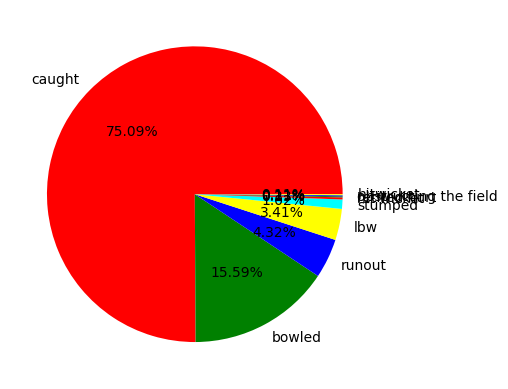

In [39]:
plt.pie( edf['count'],labels = edf['wicket_type'] , autopct='%0.2f%%', colors=['red','green','blue','yellow','cyan'] )

plt.show()

### Over by over analysis
### Average Run Rate over by over

In [40]:
df['over_number'] = df['over'].astype(int)

edf = df.groupby('over_number').agg(
    avg_runs = ('total_runs','mean'),

).reset_index()

edf['avg_runs'] = edf['avg_runs'].round(2)
edf

,over_number,avg_runs
0,1,1.39
1,2,1.54
2,3,1.64
3,4,1.71
4,5,1.67
5,6,1.69
6,7,1.46
7,8,1.49
8,9,1.47
9,10,1.32


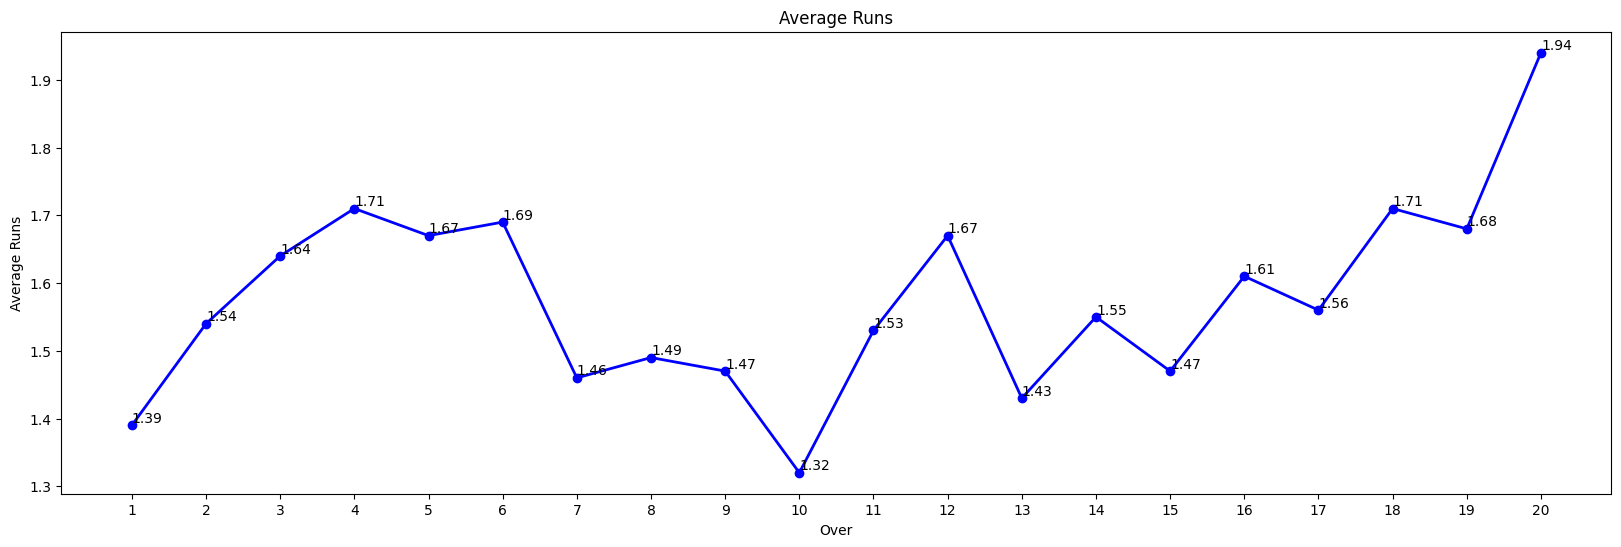

In [41]:
plt.figure(figsize=(20,6))
plt.plot(edf['over_number'],edf['avg_runs'],color='blue',marker='o',linewidth=2)
plt.title('Average Runs')
plt.xlabel('Over')
plt.ylabel('Average Runs')

plt.xticks( np.arange(1,21) )

for x,y in zip(edf['over_number'],edf['avg_runs']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

### Which team is better in Powerplay , middle or in death overs ?

In [42]:
edf = df.groupby(['batting_team','phase_group']).agg(
    total = ('total_runs','sum')
).reset_index()

edf

,batting_team,phase_group,total
0,CSK,Death(16-20),758
1,CSK,Middle(7-15),1060
2,CSK,Powerplay(1-6),705
3,DC,Death(16-20),792
4,DC,Middle(7-15),1136
5,DC,Powerplay(1-6),624
6,GT,Death(16-20),830
7,GT,Middle(7-15),1429
8,GT,Powerplay(1-6),824
9,KKR,Death(16-20),635


In [43]:
edf = df.pivot_table(index='batting_team',columns='phase_group',values='total_runs',aggfunc='sum').reset_index()
edf

phase_group,batting_team,Death(16-20),Middle(7-15),Powerplay(1-6)
0,CSK,758,1060,705
1,DC,792,1136,624
2,GT,830,1429,824
3,KKR,635,1069,607
4,LSG,746,1065,694
5,MI,758,1191,603
6,PBKS,813,1176,715
7,RCB,861,1315,878
8,RR,782,1404,885
9,SRH,839,1393,809


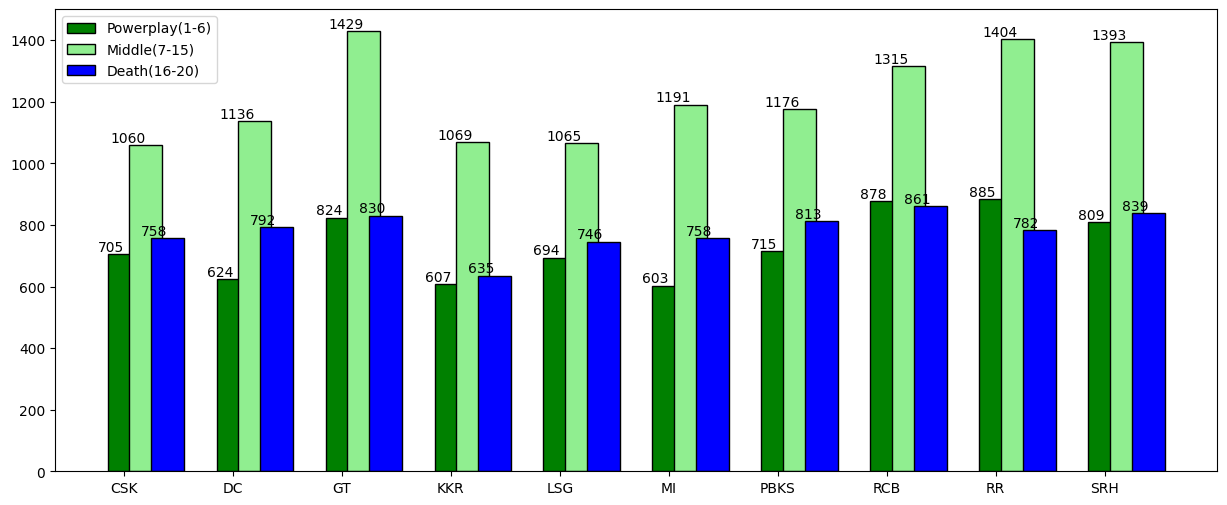

In [44]:
plt.figure(figsize=(15,6))

xval = np.arange(1,11)  #[1,2,3,4,5,6,7,8,9,10]

plt.bar(xval,edf['Powerplay(1-6)'],width=0.3,color='green',label='Powerplay(1-6)',edgecolor='black')  #[1 2 3 4 5 6 7 8 9 10]
plt.bar(xval+0.2,edf['Middle(7-15)'],width=0.3,color='lightgreen',label='Middle(7-15)',edgecolor='black') #[1.2,2.2,3.2,4.2,5.2,6.2,7.2,8.2,9.2,10.2]
plt.bar(xval+0.4,edf['Death(16-20)'],width=0.3,color='blue',label='Death(16-20)',edgecolor='black')
plt.legend()


for x,y in zip(xval,edf['Powerplay(1-6)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.2,edf['Middle(7-15)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.4,edf['Death(16-20)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')


plt.xticks(xval,edf['batting_team'])

plt.show()

# Conclusion

This project analyzed IPL 2026 ball-by-ball data using Python, Pandas, NumPy, and Matplotlib.

Key insights:
- Compared total runs scored by each team.
- Identified teams with the highest number of fours and sixes.
- Analyzed team performance in Powerplay, Middle, and Death overs.
- Studied different wicket types and their distribution.
- Created visualizations to better understand team batting performance.

This project demonstrates how data analytics can be used to generate meaningful insights from cricket match data.